## Configurações iniciais

In [1]:
#plot direto no notebook
%matplotlib inline
from ultralytics import YOLO, settings
from IPython.display import Image
import os
import pandas as pd
import matplotlib.pyplot as plt

## Definindo MODELO


In [2]:
model = YOLO("runs_obb/exp_vehicles/weights/best.pt")

In [ ]:
DATA_YAML = r"D:/Dataset_DOTA/yolo8_dataset/data.yaml"

## Exibição dos resultados


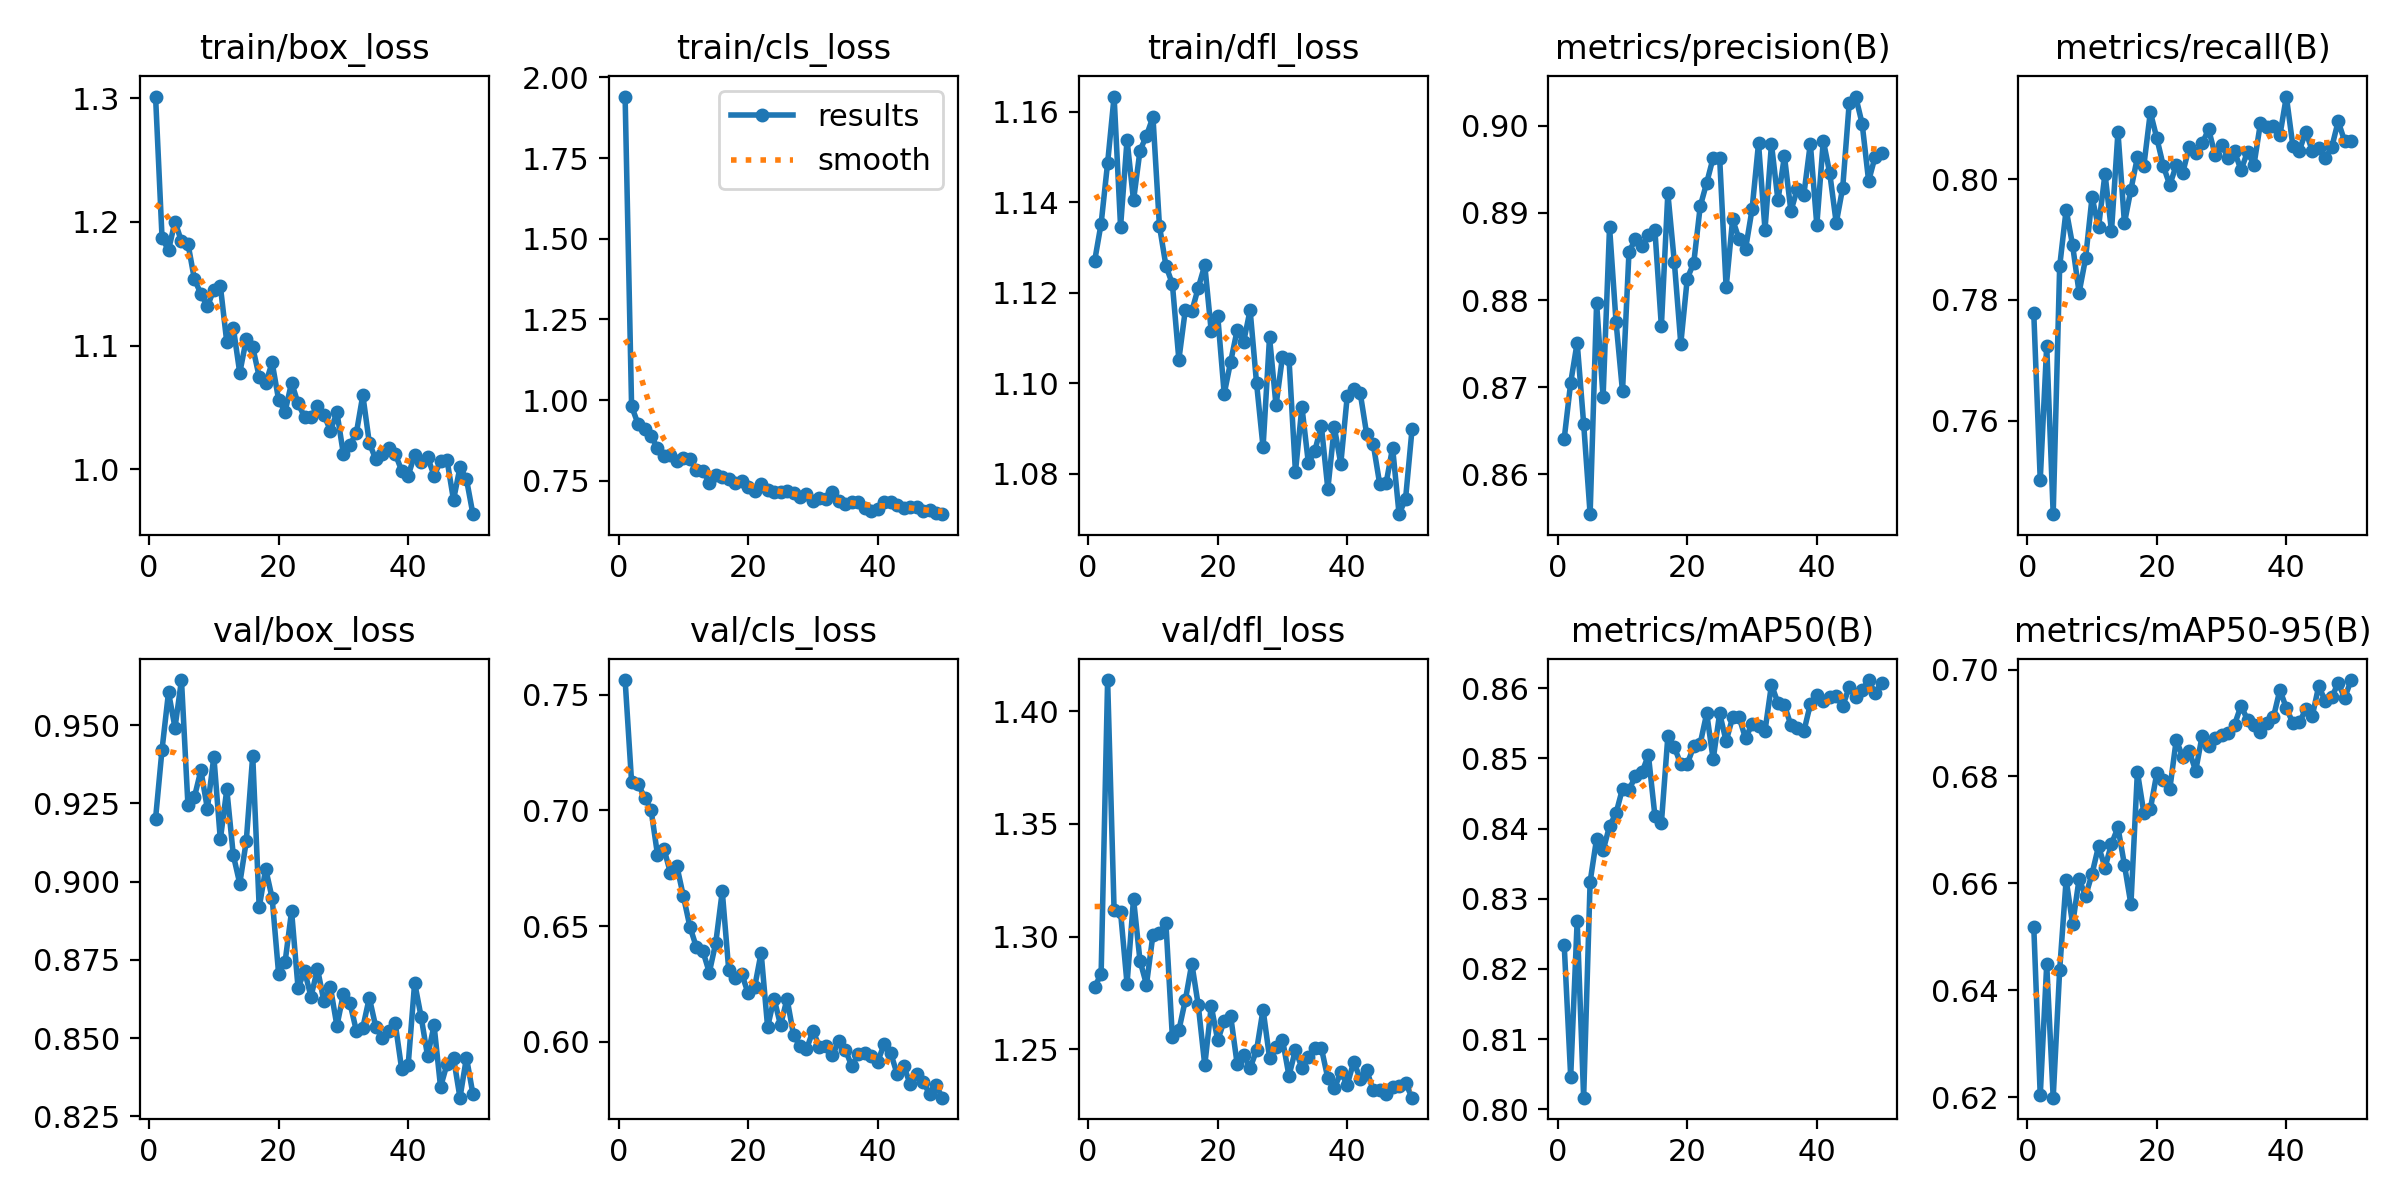

In [3]:
Image(filename="runs_obb/exp_vehicles/results.png")

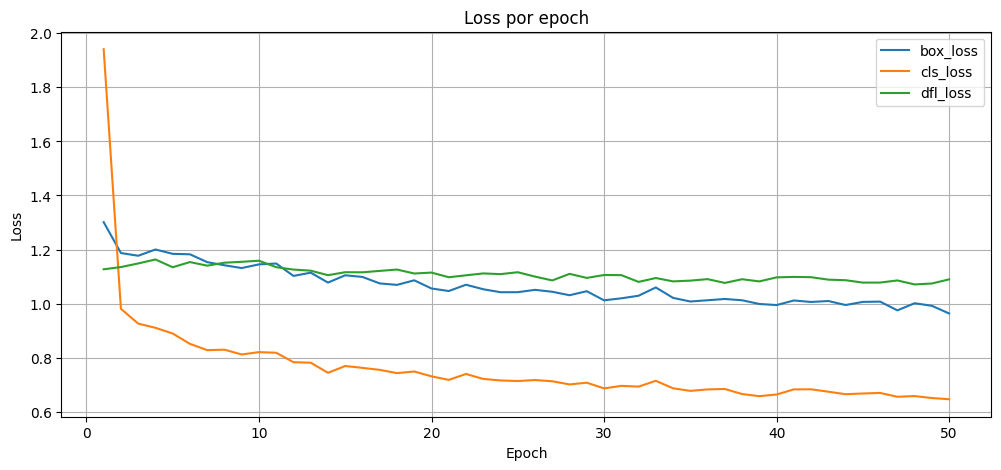

In [4]:
df = pd.read_csv("runs_obb/exp_vehicles/results.csv")

plt.figure(figsize=(12,5))

plt.plot(df["epoch"], df["train/box_loss"], label="box_loss")
plt.plot(df["epoch"], df["train/cls_loss"], label="cls_loss")
plt.plot(df["epoch"], df["train/dfl_loss"], label="dfl_loss")

plt.legend()
plt.title("Loss por epoch")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.show()

In [6]:
model = YOLO("runs_obb/exp_vehicles/weights/best.pt")

metrics = model.val(
    data=DATA_YAML,
    imgsz=1024,
    device=0
)

Ultralytics 8.3.229  Python-3.13.2 torch-2.9.1+cu128 CUDA:0 (NVIDIA GeForce RTX 2060, 6144MiB)
YOLOv8n-obb summary (fused): 81 layers, 3,077,804 parameters, 0 gradients, 8.3 GFLOPs
val: Fast image access  (ping: 7.610.1 ms, read: 59.915.6 MB/s, size: 1683.7 KB)
val: Scanning D:\Dataset_DOTA_tiles\labels\val.cache... 1254 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1254/1254 1.6Mit/s 0.0s0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 79/79 1.6it/s 48.6s0.4ss
                   all       1254      56102      0.753      0.648      0.712      0.542
         small vehicle        952      50026      0.817      0.447      0.608      0.389
         large vehicle        391       3224      0.638      0.612      0.643      0.499
                 plane        404       2852      0.806      0.885      0.884      0.736
Speed: 6.0ms preprocess, 10.5ms inference, 0.0ms loss, 6.7ms postprocess per image
Results saved to C:\Users\S

In [7]:
# ============================
#  MÉTRICAS GLOBAIS
# ============================
print("\n==== MÉTRICAS GLOBAIS ====\n")

print(f"Precision:      {metrics.box.mp:.4f}")
print(f"Recall:         {metrics.box.mr:.4f}")
print(f"mAP50:          {metrics.box.map50.mean():.4f}")
print(f"mAP50-95:       {metrics.box.map.mean():.4f}")

# ============================
#  MÉTRICAS POR CLASSE
# ============================
print("\n==== MÉTRICAS POR CLASSE ====\n")

class_names = [model.names[i] for i in range(len(model.names))]

df = pd.DataFrame({
    "Classe": class_names,
    "Precision": metrics.box.p,
    "Recall": metrics.box.r,
    "mAP50": metrics.box.map50,
    "mAP50-95": metrics.box.map
})

print(df.to_string(index=False, float_format="%.4f"))

# ============================
#  TP / FP / FN POR CLASSE
# ============================
print("\n==== TP / FP / FN POR CLASSE ====\n")

conf_matrix = metrics.confusion_matrix.matrix

tp = conf_matrix.diagonal()

fp = conf_matrix.sum(axis=0) - tp

fn = conf_matrix.sum(axis=1) - tp

n_classes = len(class_names)
tp = tp[:n_classes]
fp = fp[:n_classes]
fn = fn[:n_classes]

df_counts = pd.DataFrame({
    "Classe": class_names,
    "TP": tp.astype(int), # Convertendo para inteiro para ficar limpo
    "FP": fp.astype(int),
    "FN": fn.astype(int)
})

print(df_counts.to_string(index=False))


==== MÉTRICAS GLOBAIS ====

Precision:      0.7535
Recall:         0.6482
mAP50:          0.7115
mAP50-95:       0.5415

==== MÉTRICAS POR CLASSE ====

       Classe  Precision  Recall  mAP50  mAP50-95
small vehicle     0.8166  0.4469 0.7115    0.5415
large vehicle     0.6379  0.6123 0.7115    0.5415
        plane     0.8059  0.8853 0.7115    0.5415

==== TP / FP / FN POR CLASSE ====

       Classe    TP    FP   FN
small vehicle 26363 23663 9914
large vehicle  2179  1045 2315
        plane  2597   255  897


In [8]:
from shapely.geometry import Polygon

def obb_iou(poly1, poly2):
    """
    poly1 e poly2 são listas [x1,y1,x2,y2,x3,y3,x4,y4]
    coordenadas absolutas da imagem.
    """
    p1 = Polygon([(poly1[i], poly1[i+1]) for i in range(0,8,2)])
    p2 = Polygon([(poly2[i], poly2[i+1]) for i in range(0,8,2)])

    if not p1.is_valid or not p2.is_valid:
        return 0.0

    inter = p1.intersection(p2).area
    union = p1.union(p2).area

    if union == 0:
        return 0.0

    return inter / union


In [9]:
def yolo_obb_to_abs(obb, w, h):
    """
    Recebe: [x1,y1,x2,y2,x3,y3,x4,y4] (normalizado)
    Retorna em pixels absolutos.
    """
    obb_abs = []
    for i in range(0, 8, 2):
        obb_abs.append(obb[i]   * w)
        obb_abs.append(obb[i+1] * h)
    return obb_abs


In [10]:
import os
import cv2
import numpy as np

VAL_IMG = r"D:/Dataset_DOTA/yolo8_dataset/images/val"
VAL_LBL = r"D:/Dataset_DOTA/yolo8_dataset/labels/val"

iou_threshold = 0.3

y_true = []
y_pred = []

def yolo_obb_to_abs(obb, w, h):
    out = []
    for i in range(0, 8, 2):
        out.append(obb[i] * w)
        out.append(obb[i+1] * h)
    return out

for f in os.listdir(VAL_IMG):
    if not f.endswith(".png"):
        continue

    img_path = os.path.join(VAL_IMG, f)
    lbl_path = os.path.join(VAL_LBL, f.replace(".png", ".txt"))

    img = cv2.imread(img_path)
    h, w = img.shape[:2]

    # ------------------ GT ------------------
    gt_boxes = []
    if os.path.exists(lbl_path):
        with open(lbl_path, "r") as g:
            for line in g:
                parts = line.split()
                cls = int(parts[0])
                obb = list(map(float, parts[1:9]))
                obb = yolo_obb_to_abs(obb, w, h)
                gt_boxes.append((cls, obb))

    # ------------------ Predição ------------------
    preds = model.predict(img_path, imgsz=1024, device=0)[0]

    pred_boxes = []

    if preds.obb is not None:
        pred_cls = preds.obb.cls.cpu().numpy()
        pred_obb = preds.obb.xyxyxyxy.cpu().numpy()

    for c, obb in zip(pred_cls, pred_obb):
        # obb vem como (4,2) → achatar para 8 valores
        flat = obb.reshape(-1)  # vira [x1,y1,x2,y2,x3,y3,x4,y4]
        pred_boxes.append((int(c), flat))


    # ------------------ Matching GT × Pred ------------------
    matched_gt = set()

    for pred_cls, pred_obb in pred_boxes:

        best_iou = 0
        best_gt = None
        best_gt_idx = -1

        for i, (gt_cls, gt_obb) in enumerate(gt_boxes):
            if i in matched_gt:
                continue

            iou = obb_iou(pred_obb, gt_obb)
            if iou > best_iou:
                best_iou = iou
                best_gt = gt_cls
                best_gt_idx = i

        if best_iou >= iou_threshold:
            y_pred.append(pred_cls)
            y_true.append(best_gt)
            matched_gt.add(best_gt_idx)
        else:
            y_pred.append(pred_cls)
            y_true.append(-1)  # classe inexistente


image 1/1 D:\Dataset_DOTA\yolo8_dataset\images\val\P0003.png: 928x1024 16 small vehicles, 39 large vehicles, 47.5ms
Speed: 8.1ms preprocess, 47.5ms inference, 31.1ms postprocess per image at shape (1, 3, 928, 1024)

image 1/1 D:\Dataset_DOTA\yolo8_dataset\images\val\P0004.png: 1024x576 21 small vehicles, 83 large vehicles, 56.8ms
Speed: 6.4ms preprocess, 56.8ms inference, 4.9ms postprocess per image at shape (1, 3, 1024, 576)

image 1/1 D:\Dataset_DOTA\yolo8_dataset\images\val\P0007.png: 1024x736 59 small vehicles, 118 large vehicles, 46.3ms
Speed: 7.2ms preprocess, 46.3ms inference, 5.1ms postprocess per image at shape (1, 3, 1024, 736)

image 1/1 D:\Dataset_DOTA\yolo8_dataset\images\val\P0019.png: 608x1024 4 small vehicles, 148.0ms
Speed: 10.8ms preprocess, 148.0ms inference, 5.3ms postprocess per image at shape (1, 3, 608, 1024)

image 1/1 D:\Dataset_DOTA\yolo8_dataset\images\val\P0027.png: 800x1024 6 small vehicles, 53.2ms
Speed: 10.2ms preprocess, 53.2ms inference, 4.9ms postproc

              precision    recall  f1-score   support

           0      0.978     0.986     0.982     10200
           1      0.963     0.944     0.953      3936
           2      0.998     1.000     0.999      1937

    accuracy                          0.977     16073
   macro avg      0.980     0.976     0.978     16073
weighted avg      0.977     0.977     0.977     16073



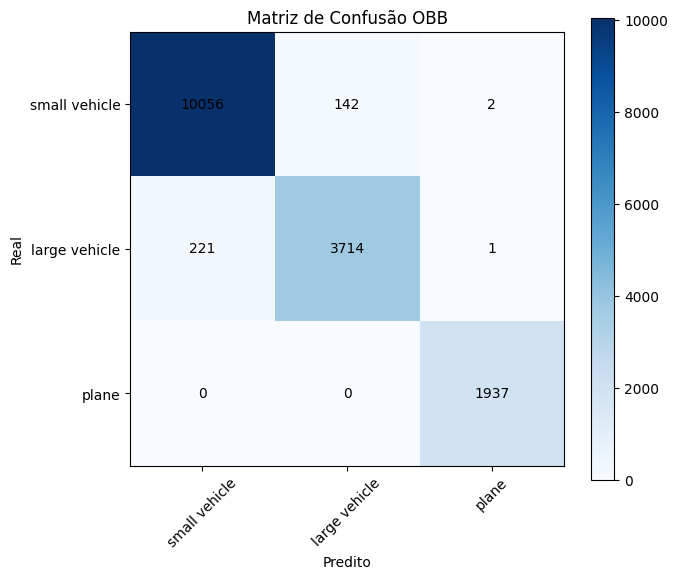

In [11]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np
import matplotlib.pyplot as plt

# remover fundo (classe -1)
valid = [i for i, y in enumerate(y_true) if y != -1]
yt = [y_true[i] for i in valid]
yp = [y_pred[i] for i in valid]

print(classification_report(yt, yp, digits=3))

labels = ["small vehicle", "large vehicle", "plane"]

cm = confusion_matrix(yt, yp)

plt.figure(figsize=(7,6))
plt.imshow(cm, cmap="Blues")

plt.xticks(np.arange(3), labels, rotation=45)
plt.yticks(np.arange(3), labels)

plt.xlabel("Predito")
plt.ylabel("Real")
plt.title("Matriz de Confusão OBB")

for i in range(3):
    for j in range(3):
        plt.text(j, i, cm[i, j], ha="center", va="center", color="black")

plt.colorbar()
plt.show()